In [22]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [23]:
def load_jsonl(path):
    data = []
    with open(path, "r") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

In [49]:
def compute_wer_stats(df):
    wer = df["wer"].values
    
    stats = {}
    
    # Basic stats
    stats["num_samples"] = len(wer)
    stats["mean"] = np.mean(wer)
    stats["median"] = np.median(wer)
    stats["std"] = np.std(wer)
    stats["min"] = np.min(wer)
    stats["max"] = np.max(wer)
    
    # Quantiles
    stats["q75"] = np.quantile(wer, 0.75)
    stats["q90"] = np.quantile(wer, 0.90)
    stats["q95"] = np.quantile(wer, 0.95)
    stats["q99"] = np.quantile(wer, 0.99)
    
    # Mass at zero
    stats["pct_zero"] = np.mean(wer == 0)
    stats["pct_le_001"] = np.mean(wer <= 0.01)
    stats["pct_le_005"] = np.mean(wer <= 0.05)
    
    # Failure rates
    stats["pct_gt_005"] = np.mean(wer > 0.05)
    stats["pct_gt_01"] = np.mean(wer > 0.10)
    stats["pct_gt_02"] = np.mean(wer > 0.20)
    
    # Trimmed means
    stats["trimmed_mean_95"] = np.mean(np.sort(wer)[:int(0.95 * len(wer))])
    stats["trimmed_mean_90"] = np.mean(np.sort(wer)[:int(0.90 * len(wer))])
    
    # CVaR-style (tail mean)
    top_10 = int(0.10 * len(wer))
    stats["cvar_10"] = np.mean(np.sort(wer)[-top_10:])
    
    top_5 = int(0.05 * len(wer))
    stats["cvar_5"] = np.mean(np.sort(wer)[-top_5:])
    
    # Conditional mean (non-zero only)
    non_zero = wer[wer > 0]
    stats["mean_given_nonzero"] = np.mean(non_zero) if len(non_zero) > 0 else 0
    
    return pd.Series(stats)

def compute_duration_correlation(df):
    if "duration_sec" not in df.columns:
        return None
    
    pearson = df["wer"].corr(df["duration_sec"], method="pearson")
    spearman = df["wer"].corr(df["duration_sec"], method="spearman")
    
    return {
        "pearson_corr": pearson,
        "spearman_corr": spearman
    }

def duration_bin_stats(df, num_bins=5):
    df = df.copy()
    df["dur_bin"] = pd.qcut(df["duration_sec"], q=num_bins, duplicates="drop")
    
    grouped = df.groupby("dur_bin").agg(
        mean_wer=("wer", "mean"),
        std_wer=("wer", "std"),
        failure_rate_01=("wer", lambda x: np.mean(x > 0.1)),
        count=("wer", "count")
    )
    
    return grouped

def heteroscedasticity_score(df, num_bins=5):
    df = df.copy()
    df["dur_bin"] = pd.qcut(df["duration_sec"], q=num_bins, duplicates="drop")
    
    grouped = df.groupby("dur_bin")["wer"].var()
    
    if len(grouped) < 2:
        return None
    
    return grouped.iloc[-1] / grouped.iloc[0]

from sklearn.linear_model import LinearRegression

def duration_regression_slope(df):
    if "duration_sec" not in df.columns:
        return None
    
    X = df["duration_sec"].values.reshape(-1, 1)
    y = df["wer"].values
    
    model = LinearRegression().fit(X, y)
    
    return model.coef_[0]

def tail_risk_by_duration(df, threshold=0.1, num_bins=5):
    df = df.copy()
    df["dur_bin"] = pd.qcut(df["duration_sec"], q=num_bins, duplicates="drop")
    
    grouped = df.groupby("dur_bin")["wer"].apply(
        lambda x: np.mean(x > threshold)
    )
    
    return grouped

def analyze_stability(df):
    print("\nDuration Correlation:")
    print(compute_duration_correlation(df))
    
    print("\nDuration Bin Stats:")
    display(duration_bin_stats(df))
    
    print("\nHeteroscedasticity Score:")
    print(heteroscedasticity_score(df))
    
    print("\nRegression Slope (WER vs Duration):")
    print(duration_regression_slope(df))
    
    print("\nTail Risk by Duration (>0.1 WER):")
    print(tail_risk_by_duration(df))

def plot_hist_kde(df, scheme=""):
    wer = df["wer"]
    
    plt.figure()
    sns.histplot(wer, bins=50, kde=True)
    plt.title("WER Distribution (Histogram + KDE) " + scheme)
    plt.xlabel("WER")
    plt.ylabel("Count")
    plt.show()

def plot_zoomed_hist(df, scheme=""):
    wer = df["wer"]
    
    plt.figure()
    sns.histplot(wer[wer <= 0.2], bins=40, kde=True)
    plt.title("WER Distribution (Zoomed 0–0.2) " + scheme)
    plt.xlabel("WER")
    plt.show()

def plot_ecdf(df, scheme=""):
    wer = np.sort(df["wer"].values)
    y = np.arange(1, len(wer)+1) / len(wer)
    
    plt.figure()
    plt.plot(wer, y)
    plt.title("ECDF of WER " + scheme)
    plt.xlabel("WER")
    plt.ylabel("Proportion ≤ WER")
    plt.grid(True)
    plt.show()

def plot_box(df, scheme=""):
    plt.figure()
    sns.boxplot(x=df["wer"])
    plt.title("WER Boxplot " + scheme)
    plt.xlabel("WER")
    plt.show()

def plot_wer_vs_duration(df, scheme=""):
    if "duration_sec" not in df.columns:
        return
    
    plt.figure()
    sns.scatterplot(x=df["duration_sec"], y=df["wer"])
    plt.title("WER vs Duration: " + scheme)
    plt.xlabel("Duration (sec)")
    plt.ylabel("WER")
    plt.show()

In [50]:
def analyze_wer_file(path, scheme=""):
    print(f"\nLoading file: {path}")
    df = load_jsonl(path)
    
    print("\nComputing statistics...")
    stats = compute_wer_stats(df)
    display(stats)

    print("\Analyze stability...")
    stab = analyze_stability(df)
    display(stab)
    
    print("\nPlotting distributions...")
    plot_hist_kde(df, scheme)
    plot_zoomed_hist(df, scheme)
    plot_ecdf(df, scheme)
    plot_box(df, scheme)
    plot_wer_vs_duration(df, scheme)
    
    return df, stats, stab

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

def extract_base_id(key):
    """
    Extract base utterance id before '__ref='.
    """
    return key.split("__ref=")[0]

def analyze_human_likeness(orig_path, new_path, threshold=4.0):
    """
    Compare perceptual and speaker similarity metrics between orig and new scheme.
    Pairing is done by base utterance id (before __ref=).
    """

    # ----------------------------
    # Load
    # ----------------------------
    df_orig = load_jsonl(orig_path)
    df_new = load_jsonl(new_path)

    # ----------------------------
    # Create base pairing key
    # ----------------------------
    df_orig["base_id"] = df_orig["key"].apply(extract_base_id)
    df_new["base_id"] = df_new["key"].apply(extract_base_id)

    # ----------------------------
    # Merge by base_id
    # ----------------------------
    df = df_orig.merge(
        df_new,
        on="base_id",
        suffixes=("_orig", "_new")
    )

    print(f"\nTotal paired samples: {len(df)}")

    # Optional sanity check
    print("Unique base_ids in orig:", df_orig["base_id"].nunique())
    print("Unique base_ids in new:", df_new["base_id"].nunique())

    # ----------------------------
    # Metrics
    # ----------------------------
    metrics = [
        "nisqa_overall",
        "nisqa_noisiness",
        "nisqa_discontinuity",
        "nisqa_coloration",
        "nisqa_loudness",
        "sim_same",
        "sim_margin"
    ]

    summary_rows = []

    # ----------------------------
    # Metric comparison
    # ----------------------------
    for metric in metrics:

        # Drop NaN rows safely
        valid = df[[f"{metric}_orig", f"{metric}_new"]].dropna()

        if len(valid) < 2:
            continue

        diff = valid[f"{metric}_new"] - valid[f"{metric}_orig"]

        t_stat, p_val = stats.ttest_rel(
            valid[f"{metric}_new"],
            valid[f"{metric}_orig"]
        )

        summary_rows.append({
            "metric": metric,
            "mean_diff": diff.mean(),
            "median_diff": diff.median(),
            "std_diff": diff.std(),
            "pct_improved": np.mean(diff > 0),
            "var_orig": valid[f"{metric}_orig"].var(),
            "var_new": valid[f"{metric}_new"].var(),
            "var_ratio_new_over_orig":
                valid[f"{metric}_new"].var() /
                (valid[f"{metric}_orig"].var() + 1e-8),
            "p_value": p_val
        })

    summary_df = pd.DataFrame(summary_rows)

    print("\n===== Metric Comparison Summary =====")
    display(summary_df)

    # ----------------------------
    # Tail analysis
    # ----------------------------
    print("\n===== Low-Quality Tail Analysis (threshold =", threshold, ") =====")

    tail_rows = []

    for metric in ["nisqa_overall", "nisqa_noisiness", "nisqa_discontinuity"]:

        valid = df[[f"{metric}_orig", f"{metric}_new"]].dropna()

        orig_low = np.mean(valid[f"{metric}_orig"] < threshold)
        new_low = np.mean(valid[f"{metric}_new"] < threshold)

        tail_rows.append({
            "metric": metric,
            "orig_low_pct": orig_low,
            "new_low_pct": new_low,
            "reduction_in_low_pct": orig_low - new_low
        })

    tail_df = pd.DataFrame(tail_rows)
    display(tail_df)

    # ----------------------------
    # Distribution plots
    # ----------------------------
    for metric in ["nisqa_overall", "nisqa_discontinuity", "nisqa_noisiness"]:
        plt.figure()
        sns.kdeplot(df[f"{metric}_orig"].dropna(), label="orig")
        sns.kdeplot(df[f"{metric}_new"].dropna(), label="new")
        plt.title(f"{metric} Distribution")
        plt.legend()
        plt.show()

    return df, summary_df, tail_df


Total paired samples: 3915
Unique base_ids in orig: 4802
Unique base_ids in new: 3948

===== Metric Comparison Summary =====


,metric,mean_diff,median_diff,std_diff,pct_improved,var_orig,var_new,var_ratio_new_over_orig,p_value
0,nisqa_overall,-0.035396,-0.033886,0.517729,0.446743,0.223516,0.205756,0.920545,1.932457e-05
1,nisqa_noisiness,-0.042413,-0.038285,0.484305,0.443934,0.190485,0.207565,1.089664,4.532452e-08
2,nisqa_discontinuity,-0.008710,-0.013425,0.329080,0.466922,0.082024,0.072987,0.889820,9.778814e-02
3,nisqa_coloration,-0.005875,-0.009953,0.302211,0.478416,0.080093,0.070049,0.874602,2.239394e-01
4,nisqa_loudness,-0.015037,-0.021780,0.330195,0.455939,0.088693,0.080833,0.911379,4.401630e-03
5,sim_same,-0.001385,-0.000549,0.090793,0.494253,0.005922,0.007000,1.182034,3.397863e-01
6,sim_margin,-0.000467,0.001918,0.235426,0.501916,0.030887,0.032475,1.051410,9.013006e-01



===== Low-Quality Tail Analysis (threshold = 4.0 ) =====


,metric,orig_low_pct,new_low_pct,reduction_in_low_pct
0,nisqa_overall,0.098340,0.118008,-0.019668
1,nisqa_noisiness,0.187995,0.221967,-0.033972
2,nisqa_discontinuity,0.030907,0.035504,-0.004598


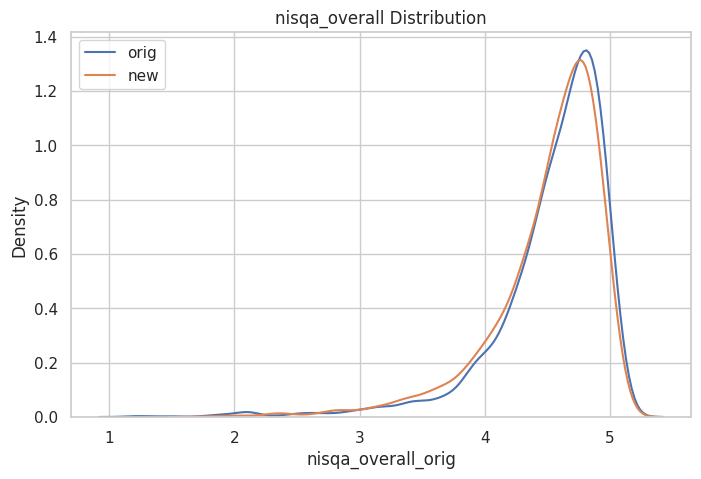

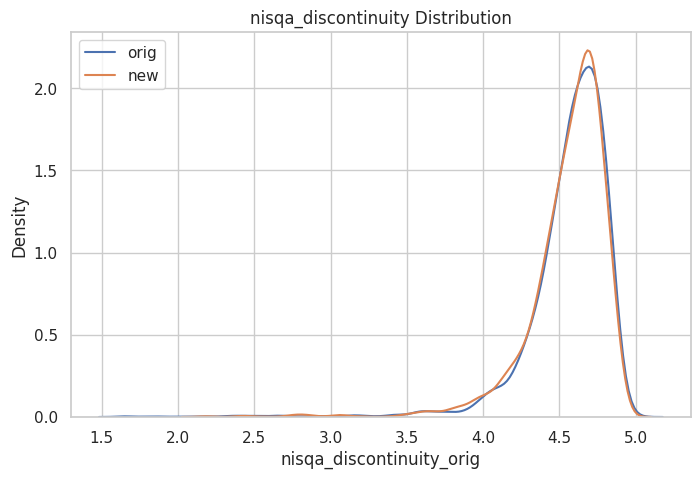

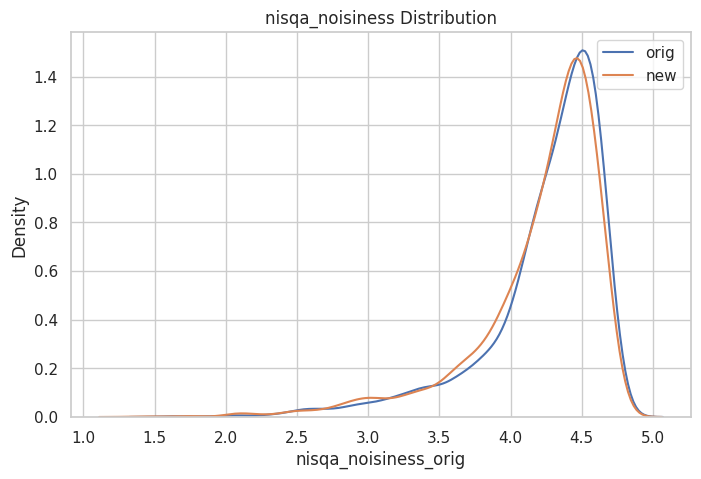

In [62]:
df_pair, summary, tail = analyze_human_likeness(
    "/data2/minh_duc/neutts_eval/libritts/asr/openai/whisper-large-v3/orig/results.jsonl",
    "/data2/minh_duc/neutts_eval/libritts/asr/openai/whisper-large-v3/rank_eas_hier/results.jsonl"
)

In [63]:
def extract_base_id(key):
    return key.split("__ref=")[0]

def analyze_wer_compare(orig_path, new_path):
    print("\nLoading files...")
    df_orig = load_jsonl(orig_path)
    df_new = load_jsonl(new_path)

    df_orig["base_id"] = df_orig["key"].apply(extract_base_id)
    df_new["base_id"] = df_new["key"].apply(extract_base_id)

    df = df_orig.merge(
        df_new,
        on="base_id",
        suffixes=("_orig", "_new")
    )

    print(f"\nTotal paired samples: {len(df)}")

    # -----------------------------------
    # Basic paired statistics
    # -----------------------------------
    diff = df["wer_new"] - df["wer_orig"]

    summary = {
        "mean_orig": df["wer_orig"].mean(),
        "mean_new": df["wer_new"].mean(),
        "mean_diff (new-orig)": diff.mean(),
        "median_diff": diff.median(),
        "std_diff": diff.std(),
        "pct_improved (new < orig)": np.mean(diff < 0),
        "pct_worse (new > orig)": np.mean(diff > 0),
        "pct_equal": np.mean(diff == 0),
        "p_value (paired t-test)": stats.ttest_rel(
            df["wer_new"],
            df["wer_orig"]
        ).pvalue
    }

    print("\n===== Paired WER Comparison =====")
    display(pd.Series(summary))

    # -----------------------------------
    # Tail risk comparison
    # -----------------------------------
    tail_stats = {
        "orig_pct_gt_0.1": np.mean(df["wer_orig"] > 0.1),
        "new_pct_gt_0.1": np.mean(df["wer_new"] > 0.1),
        "orig_pct_gt_0.2": np.mean(df["wer_orig"] > 0.2),
        "new_pct_gt_0.2": np.mean(df["wer_new"] > 0.2),
    }

    print("\n===== Tail Risk Comparison =====")
    display(pd.Series(tail_stats))

    # -----------------------------------
    # Difference distribution
    # -----------------------------------
    plt.figure()
    sns.histplot(diff, bins=50, kde=True)
    plt.axvline(0, color="red", linestyle="--")
    plt.title("WER Difference (new - orig)")
    plt.xlabel("Difference")
    plt.show()

    # -----------------------------------
    # Overlay histogram
    # -----------------------------------
    plt.figure()
    sns.kdeplot(df["wer_orig"], label="orig")
    sns.kdeplot(df["wer_new"], label="new")
    plt.title("WER Distribution Comparison")
    plt.legend()
    plt.show()

    # -----------------------------------
    # ECDF overlay
    # -----------------------------------
    for label, col in [("orig", "wer_orig"), ("new", "wer_new")]:
        sorted_wer = np.sort(df[col])
        y = np.arange(1, len(sorted_wer)+1) / len(sorted_wer)
        plt.plot(sorted_wer, y, label=label)

    plt.title("ECDF Comparison")
    plt.xlabel("WER")
    plt.ylabel("Proportion ≤ WER")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------------
    # Duration stability comparison
    # -----------------------------------
    if "duration_sec_orig" in df.columns:
        print("\n===== Duration Stability (orig) =====")
        analyze_stability(
            df.rename(columns={
                "wer_orig": "wer",
                "duration_sec_orig": "duration_sec"
            })
        )

        print("\n===== Duration Stability (new) =====")
        analyze_stability(
            df.rename(columns={
                "wer_new": "wer",
                "duration_sec_new": "duration_sec"
            })
        )

    return df


Loading files...

Total paired samples: 2618

===== Paired WER Comparison =====


mean_orig                    0.066281
mean_new                     0.059400
mean_diff (new-orig)        -0.006881
median_diff                  0.000000
std_diff                     0.221263
pct_improved (new < orig)    0.165011
pct_worse (new > orig)       0.160810
pct_equal                    0.674179
p_value (paired t-test)      0.111703
dtype: float64


===== Tail Risk Comparison =====


orig_pct_gt_0.1    0.182964
new_pct_gt_0.1     0.178380
orig_pct_gt_0.2    0.082124
new_pct_gt_0.2     0.076776
dtype: float64

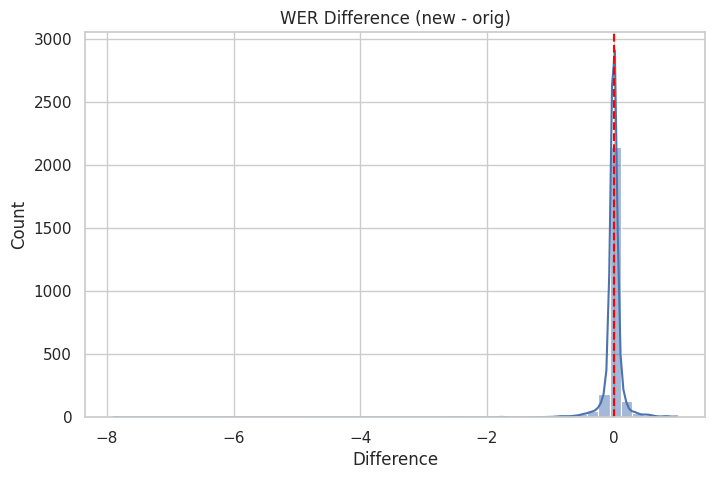

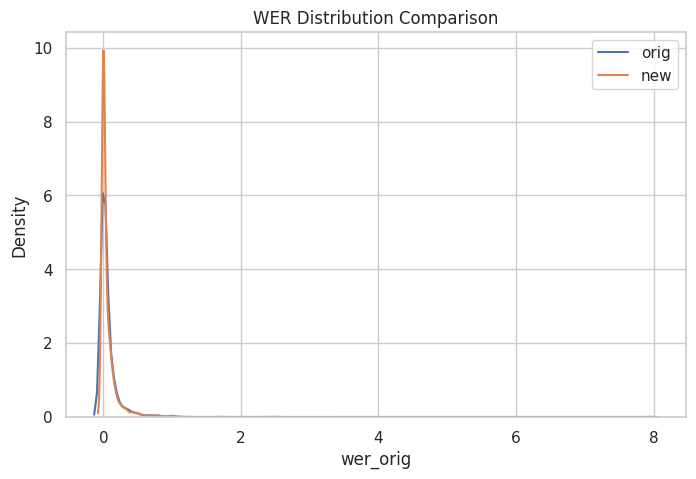

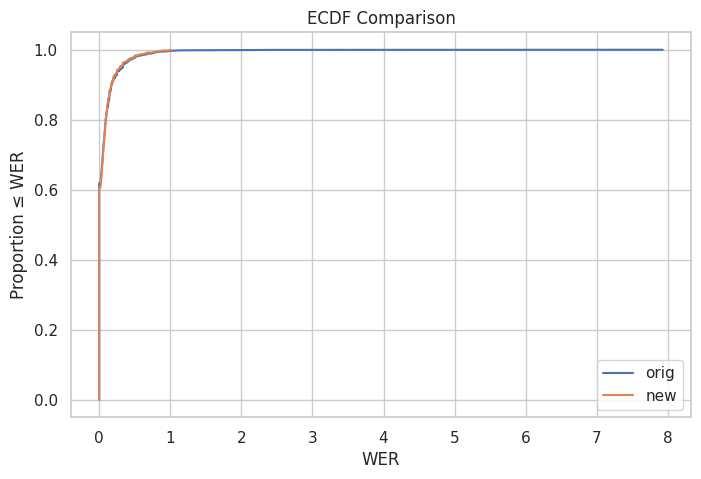


===== Duration Stability (orig) =====

Duration Correlation:
{'pearson_corr': np.float64(0.017484037470162722), 'spearman_corr': np.float64(0.13935476329675267)}

Duration Bin Stats:


/tmp/ipykernel_2804983/2331296393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("dur_bin").agg(


,mean_wer,std_wer,failure_rate_01,count
dur_bin,,,,
"(0.999, 2.96]",0.072487,0.158602,0.232381,525
"(2.96, 4.38]",0.066335,0.134865,0.215238,525
"(4.38, 6.28]",0.057489,0.163922,0.179048,525
"(6.28, 9.26]",0.065154,0.370792,0.132438,521
"(9.26, 27.94]",0.069949,0.150390,0.155172,522



Heteroscedasticity Score:
0.8991245799493249

Regression Slope (WER vs Duration):
0.0009577110415909722

Tail Risk by Duration (>0.1 WER):
dur_bin
(0.999, 2.96]    0.232381
(2.96, 4.38]     0.215238
(4.38, 6.28]     0.179048
(6.28, 9.26]     0.132438
(9.26, 27.94]    0.155172
Name: wer, dtype: float64

===== Duration Stability (new) =====

Duration Correlation:
{'pearson_corr': np.float64(-0.040782770076887014), 'spearman_corr': np.float64(0.11488961735393068)}

Duration Bin Stats:


/tmp/ipykernel_2804983/2331296393.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("dur_bin")["wer"].var()
/tmp/ipykernel_2804983/2331296393.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("dur_bin")["wer"].apply(
/tmp/ipykernel_2804983/2331296393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("dur_bin").agg(


,mean_wer,std_wer,failure_rate_01,count
dur_bin,,,,
"(0.519, 2.848]",0.085787,0.178231,0.272901,524
"(2.848, 4.22]",0.058264,0.127127,0.176471,527
"(4.22, 6.2]",0.044067,0.091394,0.157088,522
"(6.2, 9.22]",0.051332,0.102841,0.141762,522
"(9.22, 23.78]",0.057463,0.107585,0.143403,523



Heteroscedasticity Score:
0.364365815657706

Regression Slope (WER vs Duration):
-0.0013334241454495688

Tail Risk by Duration (>0.1 WER):
dur_bin
(0.519, 2.848]    0.272901
(2.848, 4.22]     0.176471
(4.22, 6.2]       0.157088
(6.2, 9.22]       0.141762
(9.22, 23.78]     0.143403
Name: wer, dtype: float64


/tmp/ipykernel_2804983/2331296393.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("dur_bin")["wer"].var()
/tmp/ipykernel_2804983/2331296393.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("dur_bin")["wer"].apply(


In [64]:
df = analyze_wer_compare(
    "/data2/minh_duc/neutts_eval/librispeech/asr/openai/whisper-large-v3/orig/results.jsonl",
    "/data2/minh_duc/neutts_eval/librispeech/asr/openai/whisper-large-v3/rank_eas_hier/results.jsonl"
)